<a href="https://colab.research.google.com/github/novakai-one/claude-ai-demo/blob/main/notebooks/fields/06_reinforcement_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Field 6 · Learning by trial and error · taste project*

# How does an agent learn to act well when rewards come later?

> **In short**
>
> **How does an agent learn to act well when rewards come later?**
>
> It keeps a score for every move in every situation. After each move it nudges that score toward "the reward I got, plus the best score from where I landed". Scores spread back from the reward, one step at a time.

## Where you'll end up

By the end you will have:

1. **A maze-solving agent** that starts knowing nothing and learns a shortest route by trial and error. You will watch its value estimates spread as a heatmap (below).
2. **The "if you knew the map" version** of the same calculation, and a check that both agree.
3. **An agent that balances a pole on a cart**, trained in the Gymnasium library.

Running every cell takes about a minute.

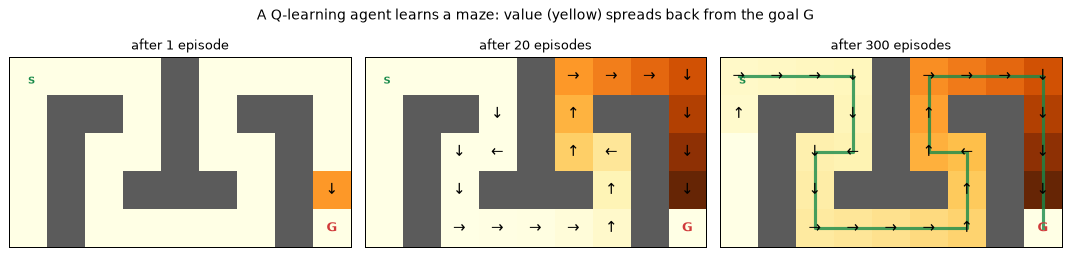

## How to use this notebook

- Run each grey code cell with **Shift + Enter**, top to bottom.
- 🤔 **Predict first** boxes ask you to guess before you run. The answer is one click away.
- 🐍 **Python notes** explain Python as it comes up.
- Exercise solutions are in collapsed cells. In Colab, double-click a solution's title to open it.

In [1]:
%pip install -q gymnasium   # the environment library used in section 6

Note: you may need to restart the kernel to use updated packages.


## 1. The problem: a reward that only comes at the end

A robot starts at **S** in this maze. `#` is a wall. It can move up, down, left or right.
It gets **+1** when it reaches **G**, and **nothing** for every other move.

Nobody gives it the map. Nobody marks good moves. It only gets that +1, many moves after the choices that earned it.
**How can it work out which early moves were good?**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

MAZE = [
    "S...#....",
    ".##.#.##.",
    ".#..#..#.",
    ".#.###.#.",
    ".#.....#G",
]
ROWS, COLS = len(MAZE), len(MAZE[0])
MOVES = [(-1, 0), (1, 0), (0, -1), (0, 1)]          # up, down, left, right
ARROWS = ["↑", "↓", "←", "→"]

class GridWorld:
    """A maze with the same reset/step interface as Gymnasium environments."""
    def __init__(self, maze=MAZE):
        self.maze = maze
        self.start = next((r, c) for r, row in enumerate(maze) for c, ch in enumerate(row) if ch == "S")
        self.goal = next((r, c) for r, row in enumerate(maze) for c, ch in enumerate(row) if ch == "G")

    def reset(self):
        self.pos = self.start
        return self.pos

    def step(self, action):
        dr, dc = MOVES[action]
        r, c = self.pos[0] + dr, self.pos[1] + dc
        if 0 <= r < ROWS and 0 <= c < COLS and self.maze[r][c] != "#":
            self.pos = (r, c)                       # walls and edges: stay put
        reached = self.pos == self.goal
        reward = 1.0 if reached else 0.0
        return self.pos, reward, reached

env = GridWorld()
print("\n".join(MAZE))
s = env.reset()
print("start:", s)
print("move right ->", env.step(3))
print("move up (a wall edge) ->", env.step(0))

S...#....
.##.#.##.
.#..#..#.
.#.###.#.
.#.....#G
start: (0, 0)
move right -> ((0, 1), 0.0, False)
move up (a wall edge) -> ((0, 1), 0.0, False)


🐍 **Python notes**
- `class GridWorld:` bundles the maze with two methods. `reset()` puts the robot at S; `step(action)` moves it and returns **(new position, reward, finished?)**. Gymnasium environments use the same pattern, so your code will work with them later.
- `next(... for ...)` returns the first item a loop produces: here, the position of "S".
- `return self.pos, reward, reached` returns three values as one tuple; `s, r, done = env.step(a)` unpacks them.

## 2. A score for every move in every square

Give every (square, move) pair a score, starting at 0. The score should end up meaning:
**"if I make this move here, then play well, how much reward will I get, and how soon?"**

After each move, nudge the score toward a **target**:

- the reward you got for this move, **plus**
- 0.9 × the best score available in the square you landed on.

The 0.9 makes a reward one step further away worth a bit less, so shorter routes score higher.

### 🤔 Predict first

The agent finishes its **first** trip to G, wandering at random. **Which squares will have a score above 0?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

**Only the square next to G** (for the move that reached G). Every earlier target was 0 + 0.9 × 0 = 0. Value spreads back about one square per trip that passes through. Check in the next cell.

</details>

In [3]:
def q_learning(env, episodes, epsilon=0.1, alpha=0.5, gamma=0.9, max_steps=5000, seed=0, snapshots=()):
    rng = np.random.default_rng(seed)
    Q = np.zeros((ROWS, COLS, 4))                   # a score for every (square, move)
    lengths, saved = [], {}
    for ep in range(1, episodes + 1):
        s = env.reset()
        for t in range(max_steps):
            if rng.random() < epsilon:
                a = int(rng.integers(4))                                    # explore: random move
            else:
                best = np.flatnonzero(Q[s] == Q[s].max())
                a = int(rng.choice(best))                                   # exploit: best move (ties at random)
            s2, r, done = env.step(a)
            target = r if done else r + gamma * Q[s2].max()
            Q[s][a] += alpha * (target - Q[s][a])                           # nudge toward the target
            s = s2
            if done:
                break
        lengths.append(t + 1)
        if ep in snapshots:
            saved[ep] = Q.copy()
    return Q, lengths, saved

def greedy_route(env, Q, limit=60):
    """Follow the best-scored move from the start. Returns the squares visited, or None if it doesn't reach the goal."""
    s, route = env.reset(), [env.start]
    for _ in range(limit):
        if s == env.goal:
            return route
        if Q[s].max() <= 0:
            return None                      # no score to follow yet
        s, _, _ = env.step(int(np.argmax(Q[s])))
        route.append(s)
    return route if s == env.goal else None

Q1, lengths1, _ = q_learning(env, episodes=1)
nonzero = [(r, c) for r in range(ROWS) for c in range(COLS) if Q1[r, c].max() > 0]
print("first trip took", lengths1[0], "moves")
print("squares with a score above 0:", nonzero, "  (G is at", env.goal, ")")

first trip took 1349 moves
squares with a score above 0: [(3, 8)]   (G is at (4, 8) )


🐍 **Python notes**
- `Q = np.zeros((ROWS, COLS, 4))` is a 3-D numpy array: one score for each row, column and move. `Q[s]` with `s = (r, c)` gives the 4 scores of that square.
- `np.flatnonzero(Q[s] == Q[s].max())` lists every move tied for best; picking among them at random stops the agent always choosing "up" when all scores are 0.
- `rng = np.random.default_rng(seed)` makes a random number generator that gives the same sequence every run.

### Watch the scores spread

In [4]:
def draw_values(ax, Q, title="", route=None):
    V = Q.max(axis=2)
    show = np.ma.masked_where(np.array([[ch == "#" for ch in row] for row in MAZE]), V)
    ax.imshow(np.array([[ch == "#" for ch in row] for row in MAZE]), cmap="Greys", vmin=0, vmax=1.4)
    ax.imshow(show, cmap="YlOrBr", vmin=0, vmax=1)
    for r in range(ROWS):
        for c in range(COLS):
            if MAZE[r][c] == "#":
                continue
            if MAZE[r][c] == "G":
                ax.text(c, r, "G", ha="center", va="center", weight="bold", color="#d03a3a")
            elif V[r, c] > 0:
                ax.text(c, r, ARROWS[int(np.argmax(Q[r, c]))], ha="center", va="center", fontsize=12)
    if route:
        rr, cc = zip(*route)
        ax.plot(cc, rr, color="#188a4a", lw=2.5, alpha=0.8)
    ax.text(0, 0, "S", ha="left", va="top", fontsize=8, color="#188a4a", weight="bold")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

from matplotlib import animation
from IPython.display import HTML

marks = [1, 2, 3, 5, 8, 12, 16, 20, 30, 40, 60, 80, 100, 150, 200, 300]
Q, lengths, saved = q_learning(env, episodes=300, snapshots=marks)

fig, ax = plt.subplots(figsize=(6, 3.6))
def frame(k):
    ax.clear()
    ep = marks[k]
    draw_values(ax, saved[ep], f"after {ep} episodes (yellow = high score; arrow = best move)",
                greedy_route(env, saved[ep]) if ep >= 60 else None)
anim = animation.FuncAnimation(fig, frame, frames=len(marks), interval=600)
plt.close(fig)
HTML(anim.to_jshtml())

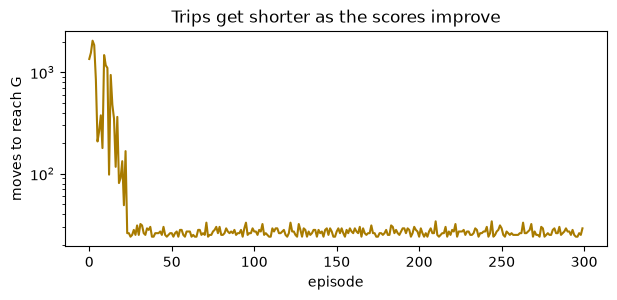

best route now: 24 moves


In [5]:
plt.figure(figsize=(7, 2.8))
plt.plot(lengths, color="#a87b00")
plt.xlabel("episode"); plt.ylabel("moves to reach G"); plt.yscale("log")
plt.title("Trips get shorter as the scores improve")
plt.show()
route = greedy_route(env, Q)
print("best route now:", len(route) - 1 if route else "doesn't reach G yet", "moves")

**What you see:** yellow spreads back from G. Arrows appear and line up into a route. Trips start at hundreds of moves and drop to the shortest route.

**What it's called:**
- each square is a **state**; each move an **action**; the +1 a **reward**
- the table `Q` is the **Q-table**; this method is **Q-learning**
- following the best arrow in every square is the agent's **policy**
- the 0.9 is the **discount**, $\gamma$; how far each nudge moves the score (0.5 here) is the **step size**, $\alpha$

**The formula** (each line of the code, written as maths):

$$Q(s, a) \leftarrow Q(s, a) + \alpha \big[\, \cy{r} + \gamma \max_{a'} Q(s', a') - Q(s, a) \,\big]$$

## 3. Try something new, or use what works?

`epsilon` is the chance of a random move instead of the best-known one.
With 0, the agent always takes its best-scored move. With 0.5, half its moves are random.

### 🤔 Predict first

Once the agent has learned the maze, **which setting gives the shortest trips: epsilon 0, 0.1 or 0.5?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

**0.** Once the scores point the right way, every random move is a detour: with 0.5, trips stay about twice the shortest length. Exploration does have a job: with more of it, the shortest route was found a few episodes sooner. Run the next cell.

</details>

In [6]:
from collections import defaultdict, deque

def shortest_route(env):
    """Fewest moves from S to G, by breadth-first search (see the Planning and search notebook)."""
    dist, q = {env.start: 0}, deque([env.start])
    while q:
        s = q.popleft()
        for dr, dc in MOVES:
            r, c = s[0] + dr, s[1] + dc
            if 0 <= r < ROWS and 0 <= c < COLS and MAZE[r][c] != "#" and (r, c) not in dist:
                dist[(r, c)] = dist[s] + 1
                q.append((r, c))
    return dist[env.goal]

best = shortest_route(env)
found, late_trips = defaultdict(list), defaultdict(list)
for eps in (0.0, 0.1, 0.5):
    for seed in range(5):
        Qe, Le, snaps = q_learning(env, episodes=200, epsilon=eps, seed=seed, snapshots=range(1, 201))
        first = next(ep for ep in range(1, 201)
                     if (r := greedy_route(env, snaps[ep])) and len(r) - 1 == best)
        found[eps].append(first)
        late_trips[eps].append(np.mean(Le[-50:]))

print(f"shortest possible route: {best} moves\n")
for eps in found:
    print(f"epsilon {eps}: shortest route found after {found[eps]} episodes;  "
          f"average trip in the last 50 episodes: {np.mean(late_trips[eps]):.1f} moves")

shortest possible route: 24 moves

epsilon 0.0: shortest route found after [24, 24, 24, 24, 24] episodes;  average trip in the last 50 episodes: 24.0 moves
epsilon 0.1: shortest route found after [24, 24, 24, 24, 24] episodes;  average trip in the last 50 episodes: 26.9 moves
epsilon 0.5: shortest route found after [21, 23, 23, 23, 24] episodes;  average trip in the last 50 episodes: 48.3 moves


🐍 **Python notes**
- `defaultdict(list)` is a dict that starts any missing key as an empty list, so `found[eps].append(...)` works the first time.
- `(r := greedy_route(...))` stores the result in `r` and tests it in one go (the "walrus" operator).

**What you see:** every setting needs about as many episodes as the route is long. Value spreads back about one square per trip, so a 24-move route needs roughly 24 trips.
More randomness finds it a little sooner, but keeps adding detours afterwards.

**What it's called:** taking random moves to discover better routes is **exploration**; using the best-known move is **exploitation**.
In mazes with traps or several possible routes, too little exploration can lock the agent onto a worse route. Balancing the two is one of the central problems of reinforcement learning.

## 4. If you knew the map: dynamic programming

Suppose you **did** know the maze. You could compute every square's value directly, without wandering:

- The value of G's neighbour is 1.
- The value of any other square is 0.9 × the best value among its neighbours.

Each value is defined using smaller versions of the same problem. Repeat the update until nothing changes.

In [7]:
def value_iteration(gamma=0.9, sweeps=100):
    V = np.zeros((ROWS, COLS))
    for sweep in range(sweeps):
        new = V.copy()
        for r in range(ROWS):
            for c in range(COLS):
                if MAZE[r][c] in "#G":
                    continue
                best = 0.0
                for dr, dc in MOVES:
                    nr, nc = r + dr, c + dc
                    if not (0 <= nr < ROWS and 0 <= nc < COLS) or MAZE[nr][nc] == "#":
                        nr, nc = r, c
                    reward = 1.0 if MAZE[nr][nc] == "G" else 0.0
                    best = max(best, reward + (0 if MAZE[nr][nc] == "G" else gamma * V[nr, nc]))
                new[r, c] = best
        if np.allclose(new, V):
            return new, sweep
        V = new
    return V, sweeps

V_exact, sweeps = value_iteration()
V_learned = Q.max(axis=2)
on_route = greedy_route(env, Q)[:-1]
print(f"value iteration settled after {sweeps} sweeps")
print("square   exact   learned by trial and error")
for s in on_route[:6]:
    print(f"{str(s):8s} {V_exact[s]:.3f}   {V_learned[s]:.3f}")

value iteration settled after 28 sweeps
square   exact   learned by trial and error
(0, 0)   0.089   0.089
(0, 1)   0.098   0.098
(0, 2)   0.109   0.109
(0, 3)   0.122   0.122
(1, 3)   0.135   0.135
(2, 3)   0.150   0.150


**What you see:** along the route, the values learned by trial and error match the exact ones closely: 1, 0.9, 0.81, …, multiplied by 0.9 per step back.

**What it's called:** "the value of a state = the best reward-plus-discounted-value of the next state" is the **Bellman equation**:

$$V(s) = \max_a \big[\, r(s, a) + \gamma\, V(s') \,\big]$$

Solving it by repeated sweeps is **value iteration**. Building each answer from answers to smaller sub-problems is **dynamic programming** (see the DSA track).
Q-learning solves the same equation without the map, from samples.

### Exercise 1

By hand: a square's score for moving right is 0.2. The move lands next to G, where the best score is 1.0. The reward for the move is 0. With $\alpha = 0.5$ and $\gamma = 0.9$, **what is the new score?**

<details><summary><b>Show the answer to exercise 1</b></summary>

Target $= 0 + 0.9 \times 1.0 = 0.9$. New score $= 0.2 + 0.5 \times (0.9 - 0.2) = 0.2 + 0.35 = $ **0.55**. It moved halfway toward the target.

</details>

## 5. A harder problem: balance a pole

A pole stands on a cart. Each step, you push the cart left or right. You get +1 for every step the pole stays up (within about 12° of upright, and the cart stays on the track).
The episode ends when it falls, or after 500 steps.

This is **CartPole**, from the **Gymnasium** library, the standard collection of environments for reinforcement learning.
The state is four numbers: cart position, cart speed, pole angle, pole spin speed.

In [8]:
import gymnasium as gym

cp = gym.make("CartPole-v1")
state, info = cp.reset(seed=0)
print("state:", np.round(state, 3), "   moves:", cp.action_space)

# a random pusher, for comparison
random_scores = []
for ep in range(20):
    s, _ = cp.reset(seed=ep)
    total, done = 0, False
    while not done:
        s, r, terminated, truncated, _ = cp.step(cp.action_space.sample())
        total += r
        done = terminated or truncated
    random_scores.append(total)
print("random pushing keeps the pole up for", np.mean(random_scores), "steps on average")

state: [ 0.014 -0.023 -0.046 -0.048]    moves: Discrete(2)
random pushing keeps the pole up for 19.8 steps on average


**Problem:** a Q-table needs a row per state, but these states are real numbers: infinitely many.
**Fix:** chop each of the four numbers into a few ranges (**bins**), so similar states share a row. Then the same Q-learning code works.

In [9]:
BINS = [np.linspace(-2.4, 2.4, 3), np.linspace(-2, 2, 5), np.linspace(-0.21, 0.21, 9), np.linspace(-2, 2, 7)]

def bucket(state):
    return tuple(int(np.digitize(x, b)) for x, b in zip(state, BINS))

def train_cartpole(episodes=2500, alpha=0.2, gamma=0.99, seed=0):
    rng = np.random.default_rng(seed)
    Q = defaultdict(lambda: np.zeros(2))
    scores = []
    for ep in range(episodes):
        epsilon = max(0.01, 1.0 - ep / (0.6 * episodes))     # explore a lot at first, less later
        s, _ = cp.reset(seed=int(rng.integers(10**6)))
        b = bucket(s)
        total, done = 0, False
        while not done:
            a = int(rng.integers(2)) if rng.random() < epsilon else int(np.argmax(Q[b]))
            s2, r, terminated, truncated, _ = cp.step(a)
            b2 = bucket(s2)
            target = r if terminated else r + gamma * Q[b2].max()
            Q[b][a] += alpha * (target - Q[b][a])
            b, total, done = b2, total + r, terminated or truncated
        scores.append(total)
    return Q, scores

import time
t0 = time.time()
Q_cp, scores = train_cartpole()
print(f"trained {len(scores)} episodes in {time.time() - t0:.0f}s")
print("average of the last 100 episodes:", np.mean(scores[-100:]))

trained 2500 episodes in 27s
average of the last 100 episodes: 465.19


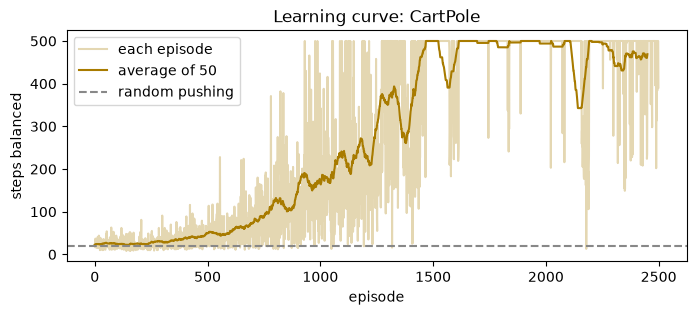

In [10]:
plt.figure(figsize=(8, 3))
plt.plot(scores, alpha=0.3, color="#a87b00", label="each episode")
plt.plot(np.convolve(scores, np.ones(50) / 50, mode="valid"), color="#a87b00", label="average of 50")
plt.axhline(np.mean(random_scores), color="#888", ls="--", label="random pushing")
plt.xlabel("episode"); plt.ylabel("steps balanced"); plt.legend(); plt.title("Learning curve: CartPole")
plt.show()

**What you see:** early episodes look like random pushing (about 20 steps). As exploration fades, the agent keeps the pole up for hundreds of steps.

A plot of score against episodes like this is a **learning curve**. It is the first thing to check when training any agent.

### Watch one balanced episode

In [11]:
from matplotlib.patches import Rectangle

def run_greedy(seed=1, limit=400):
    s, _ = cp.reset(seed=seed)
    frames = [s]
    for _ in range(limit):
        s, r, terminated, truncated, _ = cp.step(int(np.argmax(Q_cp[bucket(s)])))
        frames.append(s)
        if terminated or truncated:
            break
    return frames

frames = run_greedy()
print("balanced for", len(frames) - 1, "steps")
fig, ax = plt.subplots(figsize=(6, 2.6))
def draw_cart(k):
    ax.clear()
    x, _, theta, _ = frames[k]
    ax.add_patch(Rectangle((x - 0.25, 0), 0.5, 0.25, color="#188a4a"))
    ax.plot([x, x + 1.0 * np.sin(theta)], [0.25, 0.25 + 1.0 * np.cos(theta)], color="#d03a3a", lw=5)
    ax.axhline(0, color="#888")
    ax.set_xlim(-2.4, 2.4); ax.set_ylim(-0.1, 1.4); ax.set_aspect("equal"); ax.set_yticks([])
    ax.set_title(f"step {k}")
picks = np.linspace(0, len(frames) - 1, min(36, len(frames))).astype(int)
anim = animation.FuncAnimation(fig, lambda i: draw_cart(picks[i]), frames=len(picks), interval=120)
plt.close(fig)
HTML(anim.to_jshtml())

balanced for 369 steps


## Practice

Try each one before opening its solution.

### Exercise 2

Give every move in the maze a small cost: reward **−0.01** for each move that doesn't reach G. Train again with `epsilon=0.0`. **Does the agent find a shortest route more reliably? Why might that be?**

In [12]:
# your code here (copy GridWorld.step and change the reward)

In [13]:
#@title Solution to exercise 2 (double-click to show)
class CostlyWorld(GridWorld):
    def step(self, action):
        pos, reward, done = super().step(action)
        return pos, (reward if done else -0.01), done

def follow(env, Q, limit=100):
    # moves needed when always taking the best-scored move (None if it never arrives)
    s, n = env.reset(), 0
    while s != env.goal and n < limit:
        s, _, _ = env.step(int(np.argmax(Q[s]))); n += 1
    return n if s == env.goal else None

costly = CostlyWorld()
for seed in range(5):
    Qc, Lc, _ = q_learning(costly, episodes=200, epsilon=0.0, seed=seed)
    print("moves along the best-scored route:", follow(costly, Qc))
# Every move lowers the score of the move it took, so moves already tried look worse than untried ones (still 0).
# The agent therefore tries new moves even with epsilon 0: the small cost works like built-in exploration.

moves along the best-scored route: 24
moves along the best-scored route: 24
moves along the best-scored route: 24


moves along the best-scored route: 24
moves along the best-scored route: 24


### Exercise 3

Change the discount from 0.9 to **0.5** in `value_iteration`. **What is the value of the square 4 steps before G? Why do far squares now look almost worthless?**

In [14]:
# your code here

In [15]:
#@title Solution to exercise 3 (double-click to show)
V5, _ = value_iteration(gamma=0.5)
print(np.round(V5, 3))
# 4 steps before G: 0.5 ** 3 = 0.125. Each step back halves the value, so squares far from G are near 0.
# A small discount makes the agent short-sighted: far rewards barely count.

[[0.    0.    0.    0.    0.    0.016 0.031 0.062 0.125]
 [0.    0.    0.    0.    0.    0.008 0.    0.    0.25 ]
 [0.    0.    0.    0.    0.    0.004 0.002 0.    0.5  ]
 [0.    0.    0.    0.    0.    0.    0.001 0.    1.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.   ]]


## Recognition cues

- When you see **a reward that arrives many steps after the decisions that earned it** in a problem, think **reinforcement learning: value spreads backwards**.
- When you see **"value here = best of (reward + discounted value next)"** in a problem, think **the Bellman equation, solved by dynamic programming**.
- When you see **"keep trying new things, or stick with what works?"** in a problem, think **exploration vs exploitation (epsilon)**.
- When you see **continuous states and a table-based method** in a problem, think **bin the states (or use a neural network instead of a table)**.

## Try changing this

1. **A new maze.** Edit `MAZE` (keep one S and one G) and watch how long Q-learning takes. Add a dead end next to the start.
2. **Fewer bins.** In `BINS`, use 3 ranges for the pole angle instead of 9. Can the agent still balance it?
3. **No exploration.** Train CartPole with epsilon fixed at 0. What does the learning curve look like?

## Open research questions

People are working on these right now:

- How can agents learn from far fewer attempts? (CartPole needed thousands of episodes.)
- How do we stop agents exploiting loopholes in their reward?

Any of them could become a thesis topic.

## Spark Log

Before you close this notebook, write three things about **Learning by trial and error** in your Spark Log (the Spark Log page on the site):

1. **What surprised me?**
2. **What would I want to know next?**
3. **Excitement, 1 to 10.** How much would you enjoy a year of this?

Write it now, while it's fresh. You will compare fields later.

## Go deeper

- Sutton and Barto, *Reinforcement Learning: An Introduction* (free online): http://incompleteideas.net/book/the-book-2nd.html
- OpenAI Spinning Up (deep reinforcement learning, with code): https://spinningup.openai.com/
- At Monash: related to FIT5047 Fundamentals of AI and FIT5226 Multi-agent systems.